## ⚠️ Multiplicity and tiny-n caveat

The correlation matrix below has **n = 10 participants** and its features are per-participant **standard deviations of only 3 session values** (very high sampling variance). Starring every pairwise correlation at p<.05 with no correction, across dozens of pairs, is an almost guaranteed source of false positives. The cell below uses **Benjamini-Hochberg FDR-adjusted** p-values across all unique pairs; at n=10 only 2 of 36 pairs survive correction (down from 6 uncorrected) — and one of those is a trivial within-metric cross-session HRV correlation inflated by P01's duplicated Session 02/03 HRV_SDNN source values.

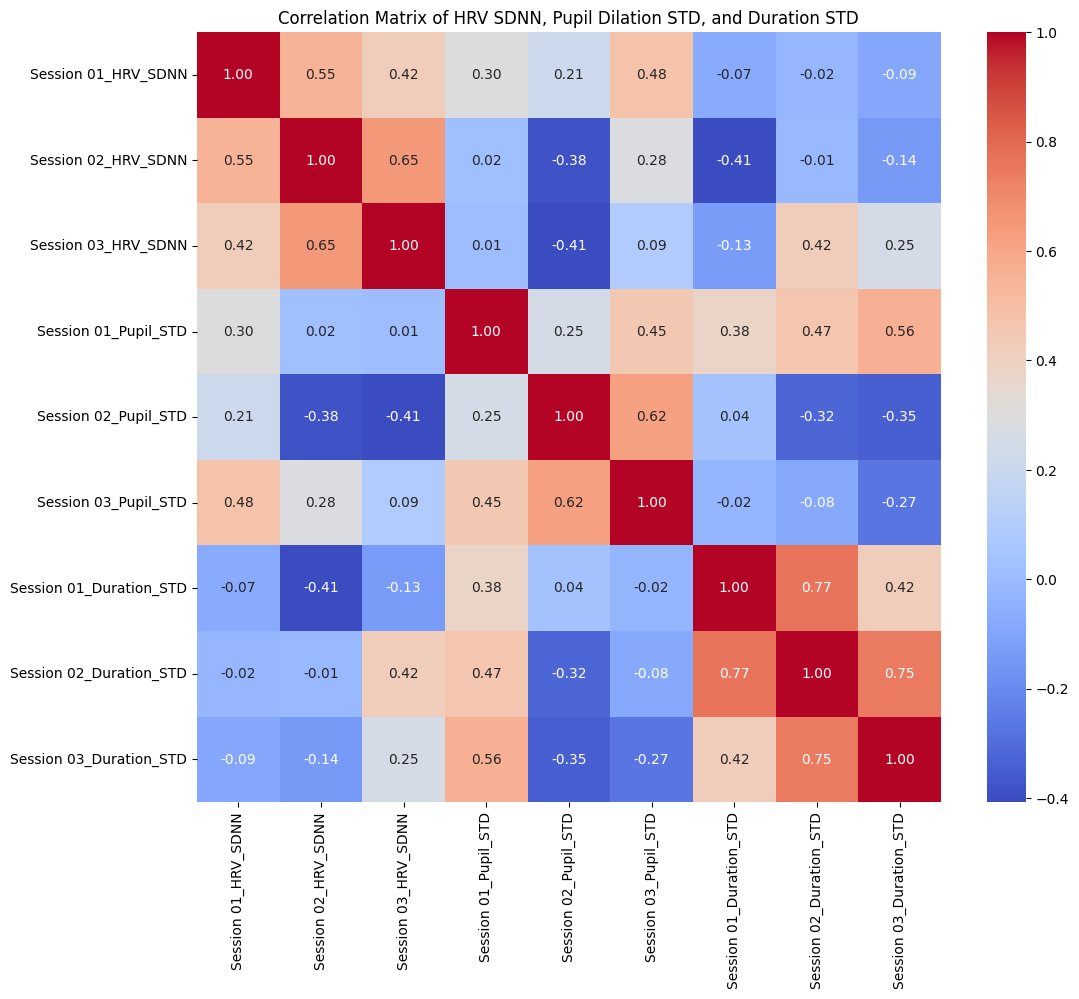

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT = '../data/group_results'

# load csv results
hrv_results_df = pd.read_csv(f'{OUTPUT}/HRV_SDNN.csv')
pupil_results_df = pd.read_csv(f'{OUTPUT}/Pupil_Dilation_STD.csv')
duration_results_df = pd.read_csv(f'{OUTPUT}/Psychometric_Test_Duration_STD.csv')

# combine with suffixes
combined_results = pd.concat([
    hrv_results_df.set_index('Participant').add_suffix('_HRV_SDNN'),
    pupil_results_df.set_index('Participant').add_suffix('_Pupil_STD'),
    duration_results_df.set_index('Participant').add_suffix('_Duration_STD'),
], axis=1)

# correlation matrix
correlation_matrix = combined_results.corr(method='spearman')

# plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of HRV SDNN, Pupil Dilation STD, and Duration STD')
plt.show()
plt.close()

Participant P01, Session 1, HRV SDNN: 80.14
Participant P01, Session 1, Pupil Dilation STD: 1.25
Participant P01, Session 2, HRV SDNN: 65.39
Participant P01, Session 2, Pupil Dilation STD: 0.61
Participant P01, Session 3, HRV SDNN: 65.39
Participant P01, Session 3, Pupil Dilation STD: 0.80
Participant P02, Session 1, HRV SDNN: 46.20
Participant P02, Session 1, Pupil Dilation STD: 0.49
Participant P02, Session 2, HRV SDNN: 47.81
Participant P02, Session 2, Pupil Dilation STD: 1.12
Participant P02, Session 3, HRV SDNN: 47.40
Participant P02, Session 3, Pupil Dilation STD: 0.48
Participant P03, Session 1, HRV SDNN: 54.98
Participant P03, Session 1, Pupil Dilation STD: 0.38
Participant P03, Session 2, HRV SDNN: 56.83
Participant P03, Session 2, Pupil Dilation STD: 0.65
Participant P03, Session 3, HRV SDNN: 39.02
Participant P03, Session 3, Pupil Dilation STD: 0.55
Participant P04, Session 1, HRV SDNN: 41.38
Participant P04, Session 1, Pupil Dilation STD: 0.42
Participant P04, Session 2, HR

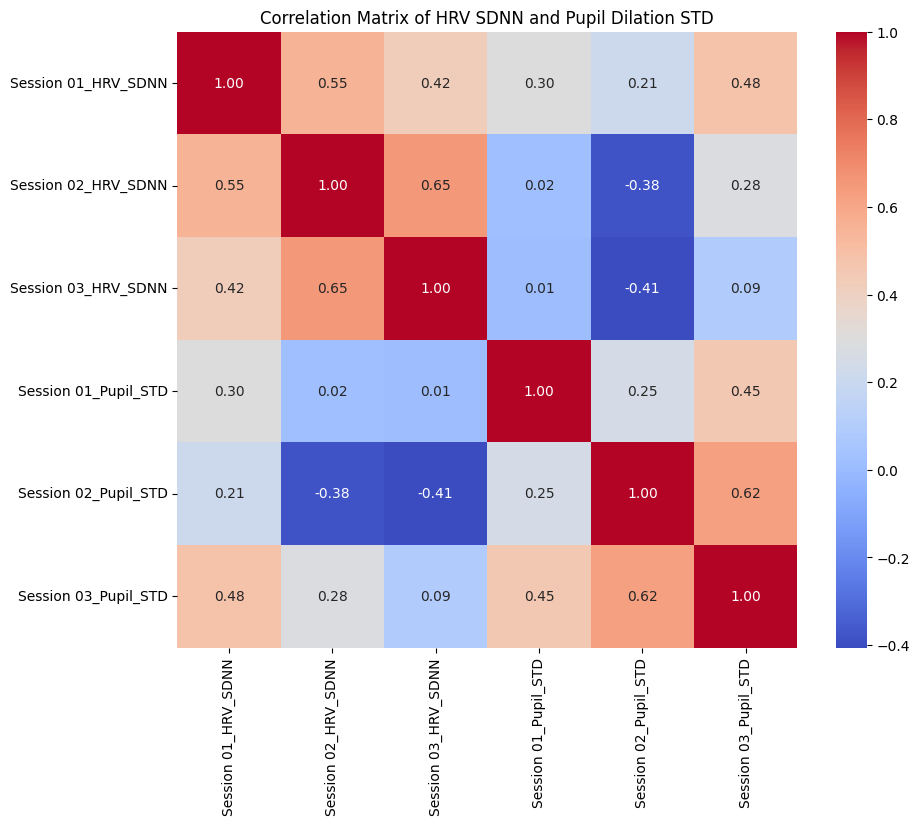

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT = '../data/group_results'

# load hrv + pupil
hrv_results_df = pd.read_csv(f'{OUTPUT}/HRV_SDNN.csv')
pupil_results_df = pd.read_csv(f'{OUTPUT}/Pupil_Dilation_STD.csv')

# indexed lookup
hrv_idx = hrv_results_df.set_index('Participant')
pupil_idx = pupil_results_df.set_index('Participant')

for pid in hrv_idx.index:
    for s in [1, 2, 3]:
        col = f'Session {s:02d}'
        print(f"Participant {pid}, Session {s}, HRV SDNN: {hrv_idx.loc[pid, col]:.2f}")
        print(f"Participant {pid}, Session {s}, Pupil Dilation STD: {pupil_idx.loc[pid, col]:.2f}")

# combine with suffixes
combined_results = pd.concat([
    hrv_results_df.set_index('Participant').add_suffix('_HRV_SDNN'),
    pupil_results_df.set_index('Participant').add_suffix('_Pupil_STD'),
], axis=1)

# correlation matrix
correlation_matrix = combined_results.corr(method='spearman')

# plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of HRV SDNN and Pupil Dilation STD')
plt.show()
plt.close()

36 unique pairs tested | significant at p<.05: 6 raw -> 2 after FDR correction


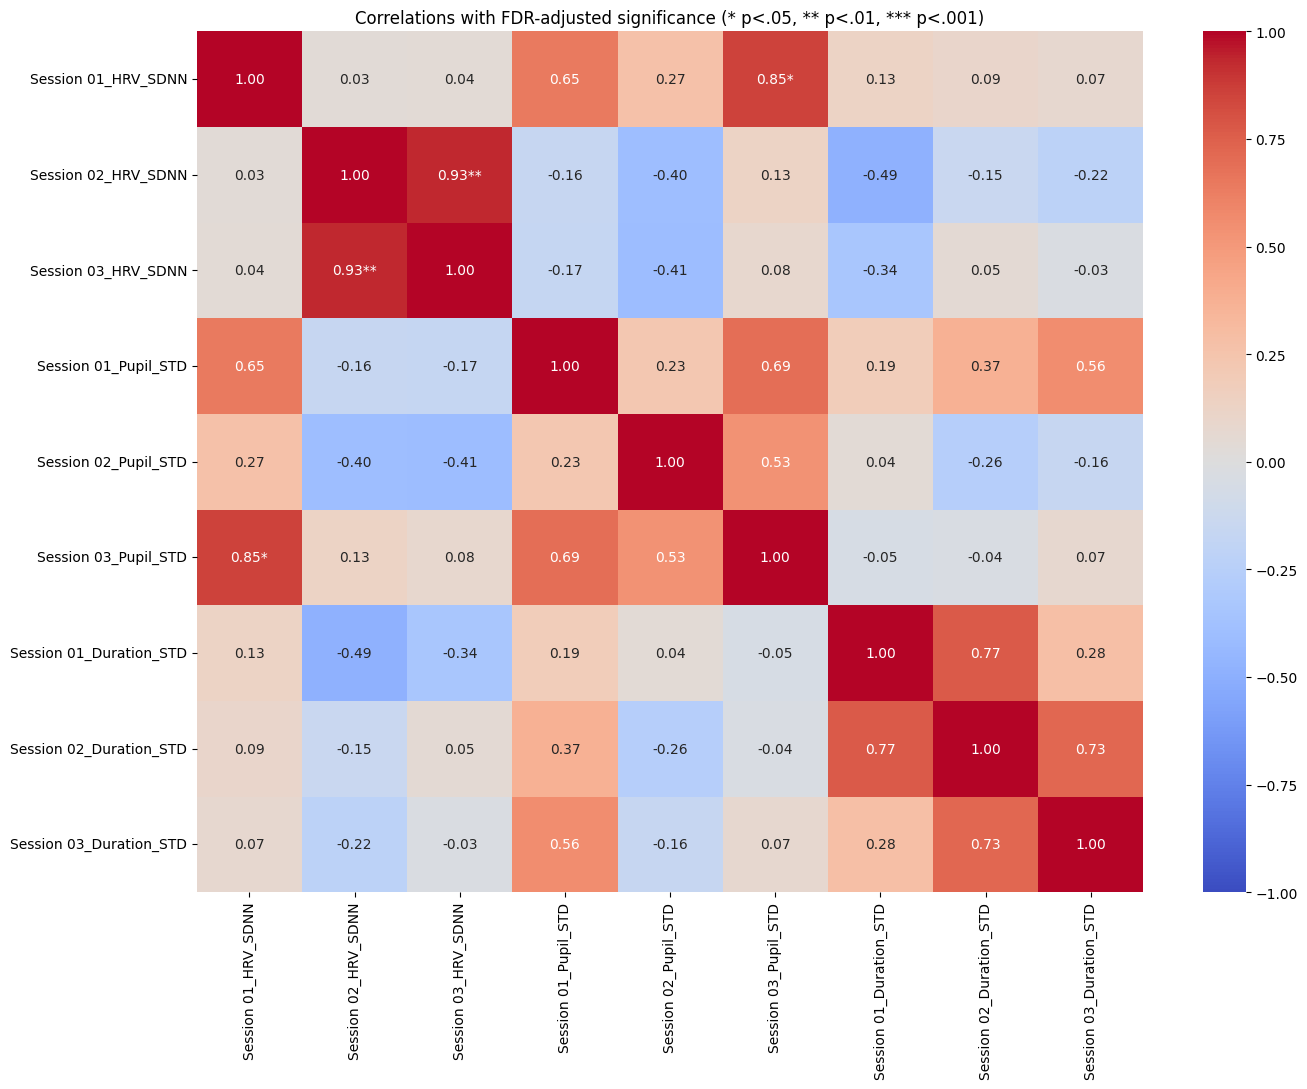

In [4]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root -> import mms
import mms
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

combined = pd.concat([
    mms.io.load_group_summary('HRV_SDNN').set_index('Participant').add_suffix('_HRV_SDNN'),
    mms.io.load_group_summary('Pupil_Dilation_STD').set_index('Participant').add_suffix('_Pupil_STD'),
    mms.io.load_group_summary('Psychometric_Test_Duration_STD').set_index('Participant').add_suffix('_Duration_STD'),
], axis=1)

res = mms.stats.corr_matrix_fdr(combined)
r, p_raw, p_fdr = res['r'], res['p_raw'], res['p_fdr']

def stars(p):
    return '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''

annot = np.empty(r.shape, dtype=object)
for i in range(r.shape[0]):
    for j in range(r.shape[1]):
        annot[i, j] = f"{r.iloc[i, j]:.2f}{stars(p_fdr.iloc[i, j])}"

iu = np.triu_indices_from(p_fdr.values, k=1)
n_raw = int((p_raw.values[iu] < .05).sum())
n_fdr = int((p_fdr.values[iu] < .05).sum())
print(f'{res["n_tests"]} unique pairs tested | significant at p<.05: '
      f'{n_raw} raw -> {n_fdr} after FDR correction')

plt.figure(figsize=(14, 11))
sns.heatmap(r, annot=annot, fmt='', cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlations with FDR-adjusted significance (* p<.05, ** p<.01, *** p<.001)')
plt.tight_layout(); plt.show(); plt.close()
